In [1]:
# ==========================================
# Importok és Beállítások
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud # Opcionális: pip install wordcloud



In [2]:
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

print("Könyvtárak betöltve.")

Könyvtárak betöltve.


Adatok mérete: (50000, 41)


,ID,credit_amount,loan_purpose,legal_entity_type,num_employees,present_res_since,property,collateral_value,has_prior_default,Operating Margin,...,OperatingCashFlowRatio,QuickRatio,WorkingCapital,AffiliateRevenueRatio,GeographicDiversification,LatePaymentCount,pl_subseg_desc,address_county,is_biased_opinion,description
0,CUST-100000,4.671197e+06,Beruházás,Egyéni Vállalkozó,1,18,Ingatlan,5.448208e+06,0,26.29,...,2.19,1.06,3.468948e+06,2.34,7.86,0,Micro,Hajdú-Bihar,0,Vendéglátás területen aktív mikrovállalkozás. ...
1,CUST-100001,3.820036e+07,Refinanszírozás,Kft.,2,42,Értékpapír,4.352504e+07,0,43.79,...,4.01,0.64,8.682209e+04,9.35,3.63,0,Micro,Vas,0,A(z) Szállítás szektorban működő Kft.. Megbízh...
2,CUST-100002,9.404669e+07,Forgóeszköz finanszírozás,Bt.,16,48,Ingatlan,1.452665e+08,0,38.48,...,1.08,0.38,-1.662379e+07,13.86,1.42,0,Small,Borsod-Abaúj-Zemplén,0,"Jelen ügyfél egy kisvállalkozás (Bt.), fő tevé..."
3,CUST-100003,2.711957e+08,Eszközbeszerzés,Zrt.,60,10,Nincs,0.000000e+00,0,41.57,...,1.04,0.59,1.888937e+08,1.63,4.98,0,Medium,Baranya,0,A(z) Vendéglátás szektorban működő Zrt.. Kieme...
4,CUST-100004,1.112975e+08,Forgóeszköz finanszírozás,Kft.,12,29,Gépjármű,2.631367e+08,0,46.22,...,2.15,0.49,3.078269e+07,1.63,8.12,0,Small,Szabolcs-Szatmár-Bereg,0,A(z) Gyártás szektorban működő Kft.. Megbízhat...



--- Adattípusok ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          50000 non-null  object 
 1   credit_amount               50000 non-null  float64
 2   loan_purpose                50000 non-null  object 
 3   legal_entity_type           50000 non-null  object 
 4   num_employees               50000 non-null  int64  
 5   present_res_since           50000 non-null  int64  
 6   property                    50000 non-null  object 
 7   collateral_value            50000 non-null  float64
 8   has_prior_default           50000 non-null  int64  
 9   Operating Margin            50000 non-null  float64
 10  Current Ratio               50000 non-null  float64
 11  EV/Revenue                  50000 non-null  float64
 12  Return on Assets (ROA)      50000 non-null  float64
 13  Return on 

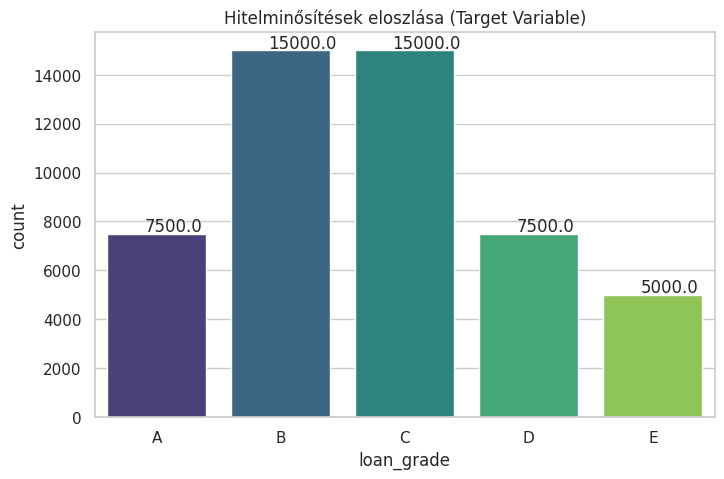

In [3]:
# ==========================================
# Adatbetöltés és Áttekintés
# ==========================================

df = pd.read_csv('synthetic_credit_data_with_bias.csv')

print(f"Adatok mérete: {df.shape}")
display(df.head())
print("\n--- Adattípusok ---")
df.info()

# Ellenőrizzük a Célváltozó (Target) eloszlását - Fontos a kiegyensúlyozatlanság miatt!
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='loan_grade', data=df, order=['A', 'B', 'C', 'D', 'E'], palette='viridis')
plt.title('Hitelminősítések eloszlása (Target Variable)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+100))
plt.show()

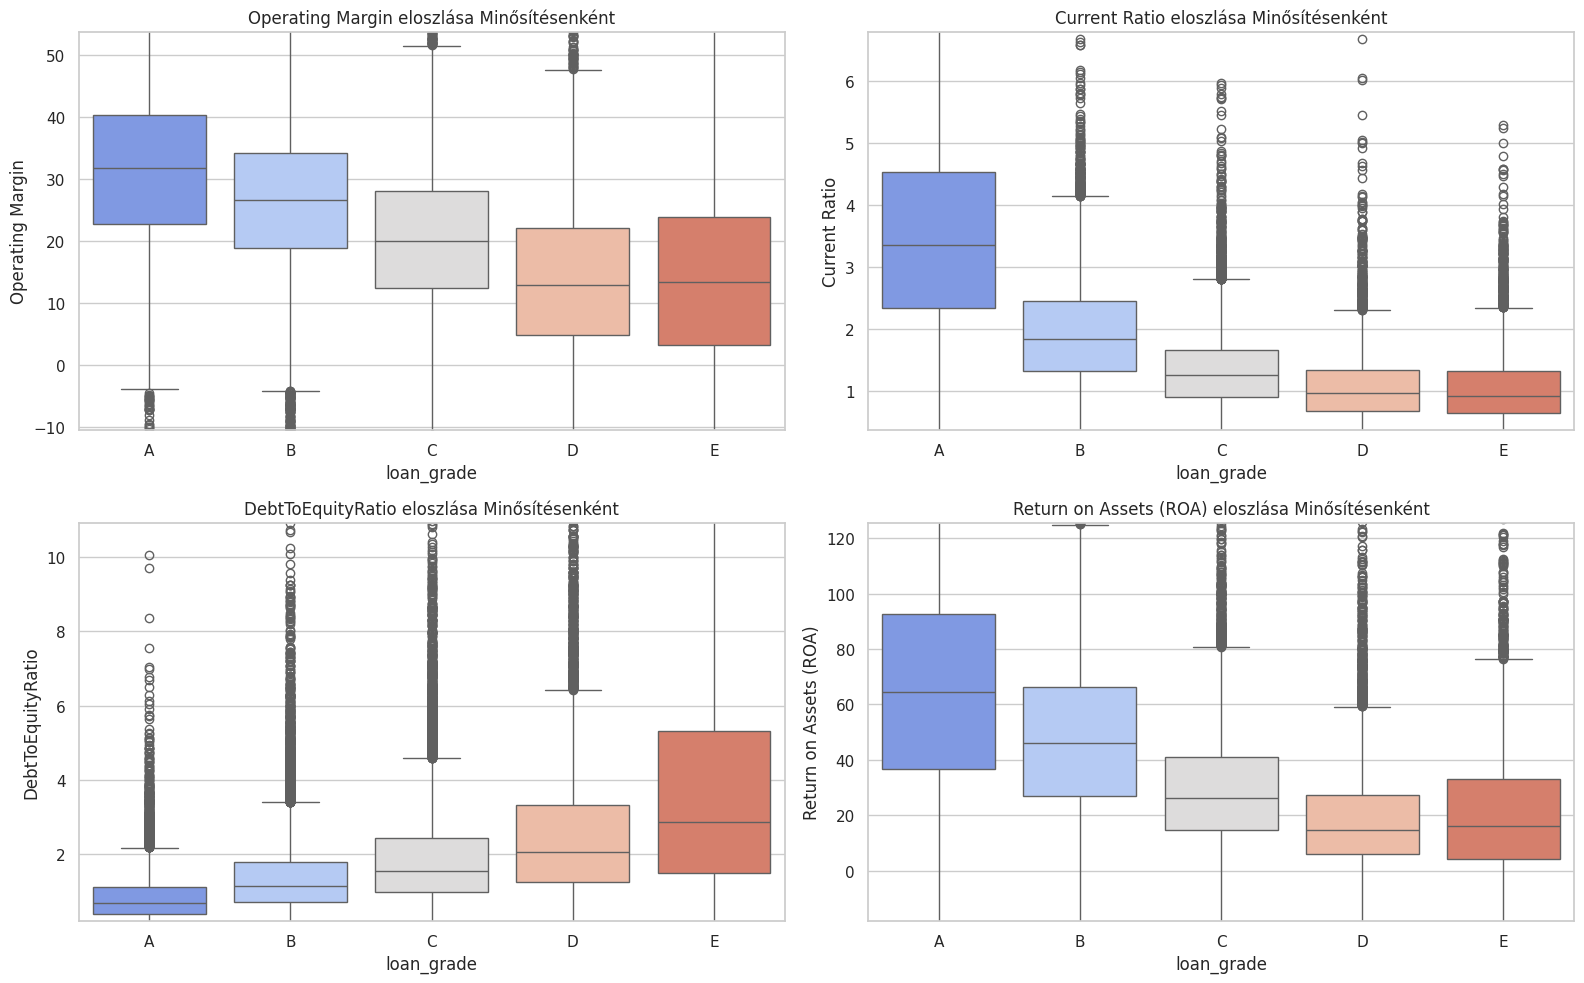

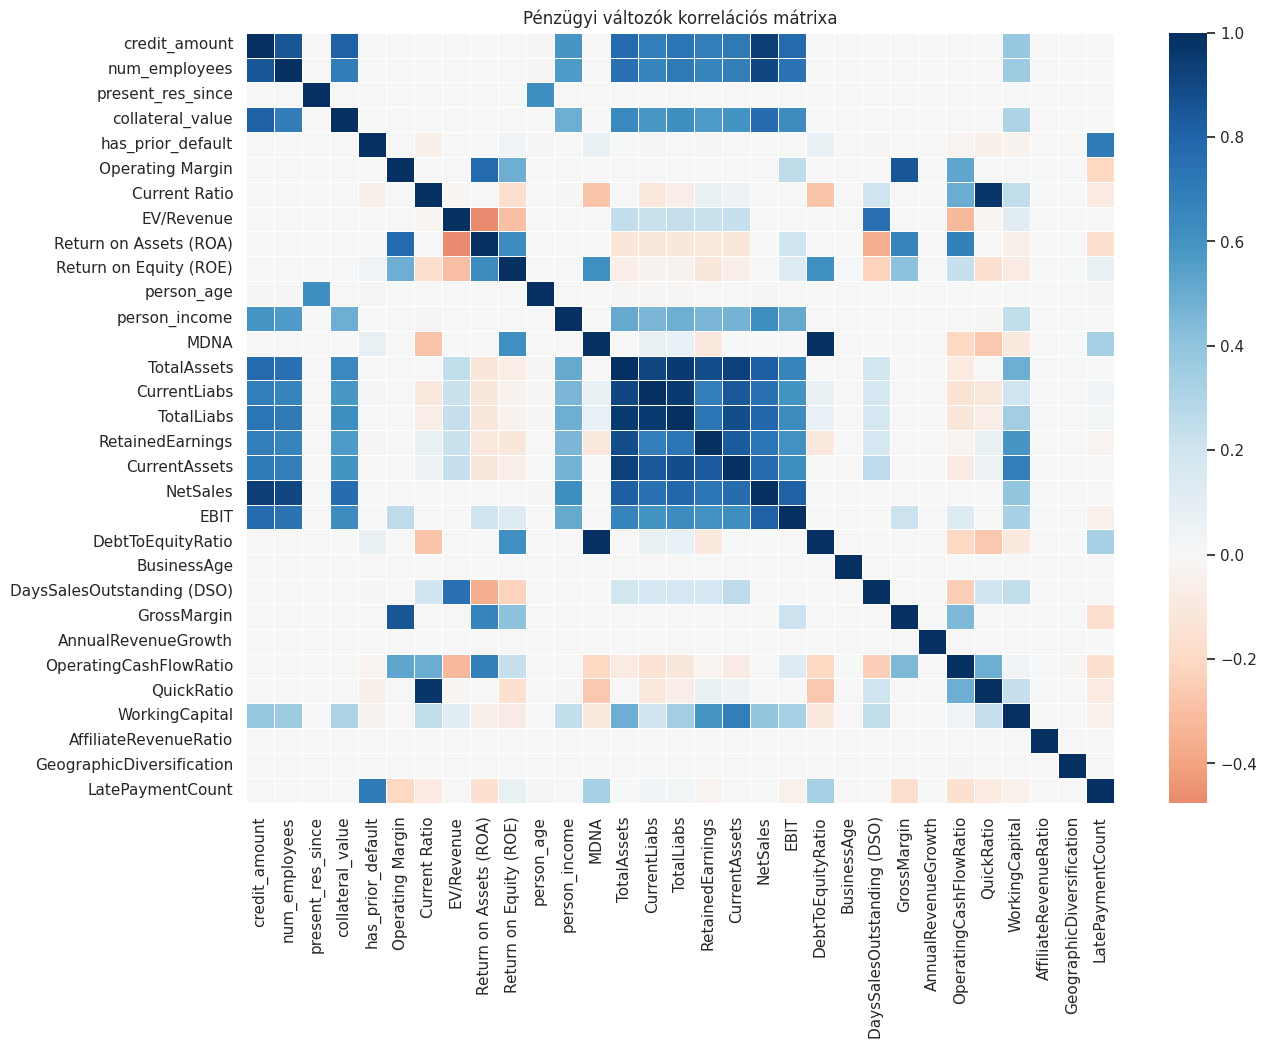

In [4]:
# ==========================================
# Részletes EDA - Pénzügyi Mutatók
# ==========================================
# Cél: Outlierek és eloszlások vizsgálata

numeric_cols = ['Operating Margin', 'Current Ratio', 'DebtToEquityRatio', 'Return on Assets (ROA)']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, col in enumerate(numeric_cols):
    # Boxplot a kategóriák szerint bontva
    sns.boxplot(x='loan_grade', y=col, data=df, order=['A', 'B', 'C', 'D', 'E'], ax=axes[i//2, i%2], palette='coolwarm')
    axes[i//2, i%2].set_title(f'{col} eloszlása Minősítésenként')
    # Levágjuk a szélsőséges outliereket a vizualizáció végett (csak a grafikonon!)
    q_low = df[col].quantile(0.01)
    q_high = df[col].quantile(0.99)
    axes[i//2, i%2].set_ylim(q_low, q_high)

plt.tight_layout()
plt.show()

# Korrelációs hőtérkép (Heatmap)
# Csak a numerikus változókat választjuk ki
corr_df = df.select_dtypes(include=[np.number]).drop(['is_biased_opinion'], axis=1, errors='ignore')
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df.corr(), cmap='RdBu', center=0, linewidths=0.5, annot=False)
plt.title('Pénzügyi változók korrelációs mátrixa')
plt.show()

Sentiment számítás futtatása...


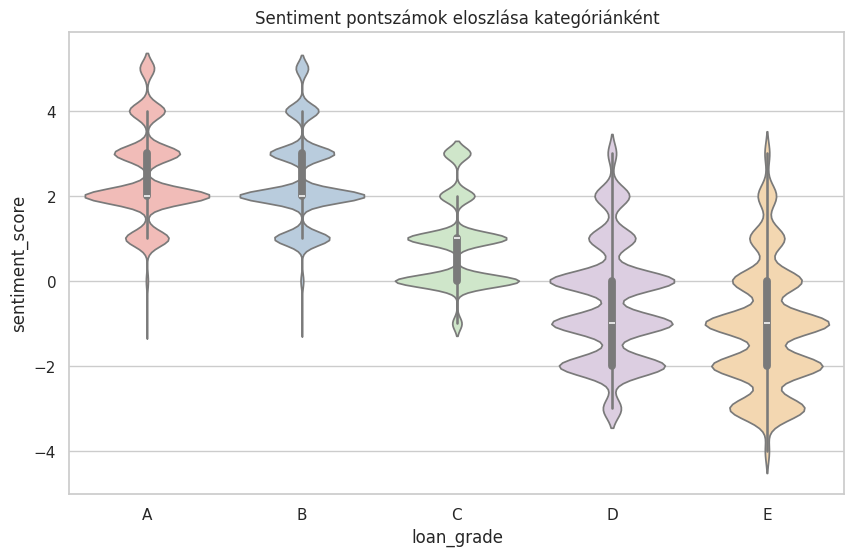

In [5]:
# ==========================================
# NLP Feature Engineering - Sentiment Analysis
# ==========================================
# Itt hozzuk létre a saját, magyar pénzügyi szótárunkat.

positive_keywords = [
    'stabil', 'erős', 'kiváló', 'pozitív', 'növekedés', 'dinamikus',
    'kiegyensúlyozott', 'megbízható', 'jó', 'rendezett', 'garancia',
    'kilábalás', 'stratégiai', 'profitabilitás', 'nyereség', 'fedezet', 'biztosított'
]

negative_keywords = [
    'kockázat', 'veszteség', 'csökken', 'negatív', 'nehézség', 'feszített',
    'gyengeség', 'romló', 'kritikus', 'nemfizetés', 'késedelem', 'probléma',
    'hiány', 'tartozás', 'bizonytalan', 'végrehajtás', 'felszámolás', 'csőd'
]

def calculate_sentiment_hu(text):
    if not isinstance(text, str): return 0
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Írásjelek törlése
    words = text.split()

    score = 0
    pos_count = 0
    neg_count = 0

    for word in words:
        if word in positive_keywords:
            score += 1
            pos_count += 1
        elif word in negative_keywords:
            score -= 1
            neg_count += 1

    # Opcionális: Normalizálás a szöveg hosszára
    # return score / len(words) if len(words) > 0 else 0
    return score

# Feature-ök generálása
print("Sentiment számítás futtatása...")
df['sentiment_score'] = df['description'].apply(calculate_sentiment_hu)
df['text_length'] = df['description'].apply(lambda x: len(str(x).split()))

# Vizualizáció: Sentiment vs Grade
plt.figure(figsize=(10, 6))
sns.violinplot(x='loan_grade', y='sentiment_score', data=df, order=['A', 'B', 'C', 'D', 'E'], palette='Pastel1')
plt.title('Sentiment pontszámok eloszlása kategóriánként')
plt.show()

In [6]:
# ==========================================
# Fejlett NLP - TF-IDF Vektorizáció
# ==========================================
# A Sentiment Score csak egy szám. A TF-IDF segít megtalálni a KULCSSZAVAKAT.
# Ez létrehoz oszlopokat pl: "word_veszteség", "word_stabil"

print("TF-IDF vektorizáció...")
# Csak a top 20 legfontosabb szót vesszük ki, hogy ne legyen túl sok oszlop
tfidf = TfidfVectorizer(max_features=20, min_df=0.01, stop_words=None)
tfidf_matrix = tfidf.fit_transform(df['description'].fillna(''))

# DataFrame-be alakítás
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"tfidf_{w}" for w in tfidf.get_feature_names_out()])

# Hozzáfűzzük az eredeti táblához
df_processed = pd.concat([df, tfidf_df], axis=1)

print(f"Új oszlopok hozzáadva: {tfidf_df.columns.tolist()}")

TF-IDF vektorizáció...
Új oszlopok hozzáadva: ['tfidf_db', 'tfidf_egy', 'tfidf_fedezet', 'tfidf_fizetési', 'tfidf_fő', 'tfidf_főbb', 'tfidf_hitelcél', 'tfidf_huf', 'tfidf_ingatlan', 'tfidf_jelen', 'tfidf_kft', 'tfidf_kockázati', 'tfidf_késedelem', 'tfidf_mikrovállalkozás', 'tfidf_mutatókkal', 'tfidf_szektorban', 'tfidf_tevékenysége', 'tfidf_tényezők', 'tfidf_érték', 'tfidf_ügyfél']


In [7]:
# ==========================================
# Mentés a modellezéshez
# ==========================================
# Eldobjuk azokat az oszlopokat, amiket a modell nem tud értelmezni (raw text, ID)
# A 'is_biased_opinion'-t megtartjuk tesztelésre, de a tanításnál majd kivesszük!

drop_cols = ['ID', 'description']
df_final = df_processed.drop(columns=drop_cols)

# Mentés
df_final.to_csv('processed_credit_data.csv', index=False)
print("Adat előkészítés kész. Fájl mentve: processed_credit_data.csv")

Adat előkészítés kész. Fájl mentve: processed_credit_data.csv
